# xrgrad Quickstart — Calculus on a lon/lat Grid

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xrtoolz/blob/main/docs/notebooks/xrgrad_quickstart.ipynb)

`xrgrad` is the finite-difference calculus package of the xrtoolz workspace: partial derivatives and vector-calculus operators (`∇`, `∇·`, `∇×`, `Δ`) on labeled xarray grids, with geometry dispatch that turns lon/lat degrees into physical metres automatically. This notebook builds a synthetic sea-surface-height eddy and walks the full chain from field to derived dynamics.

**What you'll learn:**

1. Geometry dispatch — the same `partial` call on cartesian and spherical grids.
2. Spherical derivatives — geostrophic velocities from SSH via the metric factors $\tfrac{1}{R\cos\varphi}\partial_\lambda$ and $\tfrac{1}{R}\partial_\varphi$.
3. Relative vorticity via `curl`, including the spherical curvature correction.
4. Cell areas from `grid_metrics_from_coords` for area-weighted integrals.

## Setup

In [1]:
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xrtoolz-grad @ git+https://github.com/jejjohnson/xrtoolz@main#subdirectory=packages/xrtoolz-grad",
        ],
        check=True,
    )

In [2]:
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import xrgrad

In [3]:
import importlib.util

try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,xarray,matplotlib,xrgrad",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.16.1

numpy     : 2.5.2
xarray    : 2026.7.0
matplotlib: 3.11.1
xrgrad    : 0.0.1

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.5-fc-v20
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## A synthetic eddy on a lon/lat grid

A Gaussian sea-surface-height anomaly on a 0.25° grid in the mid-latitude North Atlantic. In geostrophic balance an SSH high drives an anticyclonic (clockwise, in the northern hemisphere) circulation — exactly what the derivatives below should recover.

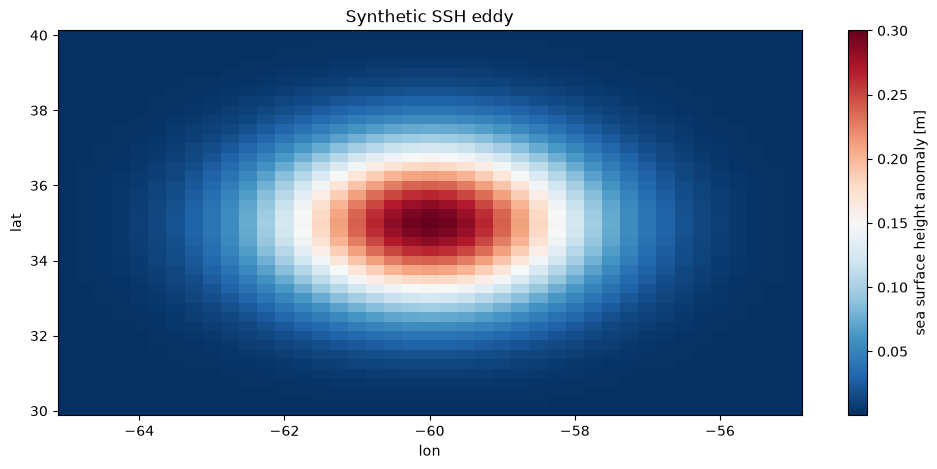

In [4]:
lon = np.arange(-65.0, -54.75, 0.25)
lat = np.arange(30.0, 40.25, 0.25)
LON, LAT = np.meshgrid(lon, lat)

amplitude = 0.3  # metres
sigma = 1.5  # degrees
ssh = xr.DataArray(
    amplitude * np.exp(-(((LON + 60.0) ** 2 + (LAT - 35.0) ** 2) / (2 * sigma**2))),
    dims=("lat", "lon"),
    coords={"lat": lat, "lon": lon},
    name="ssh",
    attrs={"units": "m", "long_name": "sea surface height anomaly"},
)

fig, ax = plt.subplots(figsize=(12, 5))
ssh.plot(ax=ax, cmap="RdBu_r")
ax.set_title("Synthetic SSH eddy")
plt.show()

## Geometry dispatch in one line

Every `xrgrad` operator takes `geometry=`. On a `"spherical"` grid the coordinate values are degrees, so a longitude derivative must be scaled by $\tfrac{1}{R\cos\varphi}$ to become a true $\partial/\partial x$ in SI units — `xrgrad` does that internally:

$$\frac{\partial \eta}{\partial x} = \frac{1}{R\cos\varphi}\frac{\partial \eta}{\partial \lambda}$$

In [5]:
deta_dx = xrgrad.partial(ssh, "lon", geometry="spherical")
deta_dy = xrgrad.partial(ssh, "lat", geometry="spherical")
print(f"peak |∂η/∂x| ≈ {float(np.abs(deta_dx).max()):.2e} m/m")

peak |∂η/∂x| ≈ 1.32e-06 m/m


## Geostrophic velocities

With the Coriolis parameter $f = 2\Omega\sin\varphi$ (using `xrgrad.OMEGA`), geostrophic balance gives

$$u_g = -\frac{g}{f}\frac{\partial \eta}{\partial y}, \qquad v_g = \frac{g}{f}\frac{\partial \eta}{\partial x}.$$

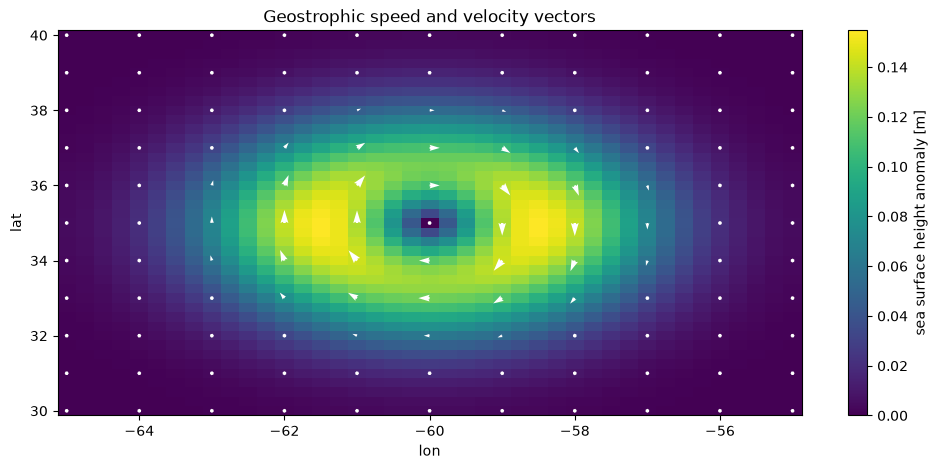

In [6]:
f_cor = 2.0 * xrgrad.OMEGA * np.sin(np.deg2rad(ssh["lat"]))
u_g = (-(xrgrad.GRAVITY / f_cor) * deta_dy).rename("u_g")
v_g = ((xrgrad.GRAVITY / f_cor) * deta_dx).rename("v_g")

fig, ax = plt.subplots(figsize=(12, 5))
speed = np.hypot(u_g, v_g).rename("speed")
speed.plot(ax=ax, cmap="viridis")
step = 4
ax.quiver(
    ssh["lon"][::step],
    ssh["lat"][::step],
    u_g[::step, ::step],
    v_g[::step, ::step],
    color="white",
    scale=8.0,
)
ax.set_title("Geostrophic speed and velocity vectors")
plt.show()

## Relative vorticity

`curl` computes $\zeta = \partial v/\partial x - \partial u/\partial y$ and, for spherical geometry, adds the curvature correction $+u\tan\varphi/R$ so the result matches `metpy.calc.vorticity` on lon/lat fields. The anticyclone shows as a negative-vorticity core ringed by positive shear, and normalising by $f$ gives the dimensionless Rossby number of the eddy.

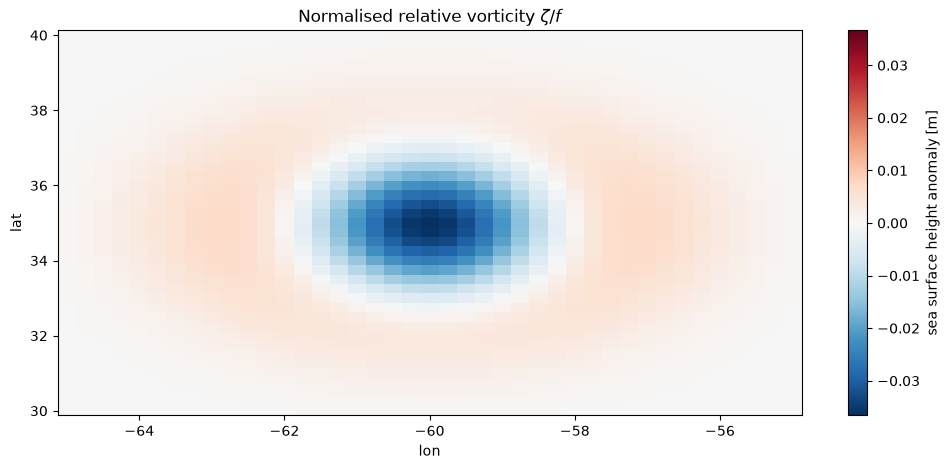

In [7]:
ds_vel = xr.Dataset({"u_g": u_g, "v_g": v_g})
zeta = xrgrad.curl(ds_vel, ("u_g", "v_g"), dims=("lon", "lat"), geometry="spherical")
rossby = (zeta / f_cor).rename("zeta_over_f")

fig, ax = plt.subplots(figsize=(12, 5))
rossby.plot(ax=ax, cmap="RdBu_r", center=0.0)
ax.set_title(r"Normalised relative vorticity $\zeta / f$")
plt.show()

## Cell areas and area-weighted integrals

`grid_metrics_from_coords` derives cell widths and areas from the coordinates alone — on a 0.25° grid the meridional spacing is a constant ≈28 km while the zonal spacing shrinks with $\cos\varphi$. These metric Datasets are what `xrtoolz.budgets` consumes, and they make area-weighted diagnostics one line.

In [8]:
vol, face = xrgrad.grid_metrics_from_coords(ssh.to_dataset())
eddy_volume = float((ssh * vol["cell_area"]).sum())
print(f"dy ≈ {float(vol['dy'].isel(lat=0)) / 1000:.1f} km per cell")
print(f"dx at 30°N ≈ {float(vol['dx'].sel(lat=30.0).isel(lon=0)) / 1000:.1f} km per cell")
print(f"eddy volume anomaly ≈ {eddy_volume / 1e9:.1f} km³")

dy ≈ 27.8 km per cell
dx at 30°N ≈ 24.1 km per cell
eddy volume anomaly ≈ 42.9 km³


## Takeaways

1. One `geometry=` keyword moves the same operator between uniform-cartesian, rectilinear, and lon/lat-degree grids — the metric factors and curvature corrections are applied for you.
2. `partial` / `gradient` / `curl` / `divergence` / `laplacian` compose into real dynamics in a few lines: SSH → geostrophic velocities → vorticity.
3. `grid_metrics_from_coords` turns coordinates into the cell/face metric Datasets used for budgets and area-weighted statistics.

For the full API, see the [Calculus reference](../api/calc.md); for the maths, the [xrtoolz-grad package page](../packages/grad.md).